# Skip-gram Word2Vec
This notebook implements the Skip-gram version of Word2Vec on the Rotten Tomatoes movie review dataset.

## 1. Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import Counter
import re
from datasets import load_dataset
from tqdm import tqdm

## 2. Loading a dataset

In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\d', ' ', text)
    return text.strip()

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")
train_texts = [preprocess_text(t) for t in ds['train']['text'][:1000]]
train_labels = ds['train']['label']

## 3. Prepare training pairs

In [13]:
corpus = " ".join(train_texts)
words = corpus.split()
vocab = list(set(words))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for i, w in word2idx.items()}
V = len(vocab)

window_size = 2
data = []
for i in range(window_size, len(words) - window_size):
    target = words[i]
    context = words[i-window_size:i] + words[i+1:i+window_size+1]
    for ctx_word in context:
        data.append((target, ctx_word))

## 4. Model setup

In [ ]:
embedding_dim = 10
W1 = np.random.randn(V, embedding_dim)
W2 = np.random.randn(embedding_dim, V)

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

def forward(target_idx):
    h = W1[target_idx]
    u = np.dot(h, W2)
    y_pred = softmax(u)
    return y_pred, h

def backward(target_idx, context_idx, y_pred, h, lr=0.05):
    global W1, W2
    e = y_pred.copy()
    e[context_idx] -= 1
    dW2 = np.outer(h, e)
    dW1 = np.dot(W2, e)
    W1[target_idx] -= lr * dW1
    W2 -= lr * dW2

selected_words = vocab[:10]
selected_idxs = [word2idx[w] for w in selected_words]
embeddings_before = W1[selected_idxs]
cos_sim_before = np.dot(embeddings_before, embeddings_before.T) / (
    np.linalg.norm(embeddings_before, axis=1)[:, None] * np.linalg.norm(embeddings_before, axis=1)[None, :]
)

## 5. Training loop

In [ ]:
epochs = 10
for epoch in tqdm(range(epochs)):
    for target, context in data[:50000]:
        target_idx = word2idx[target]
        context_idx = word2idx[context]
        y_pred, h = forward(target_idx)
        backward(target_idx, context_idx, y_pred, h)
    print(f"Epoch {epoch+1} finished")

 10%|█         | 1/10 [00:18<02:48, 18.72s/it]

Epoch 1


 20%|██        | 2/10 [00:37<02:31, 18.90s/it]

Epoch 2


 30%|███       | 3/10 [00:55<02:09, 18.46s/it]

...

Epoch 8


 90%|█████████ | 9/10 [05:30<00:44, 44.54s/it]

Epoch 9


100%|██████████| 10/10 [06:27<00:00, 38.72s/it]

Epoch 10


## 6. Visualization and analysis

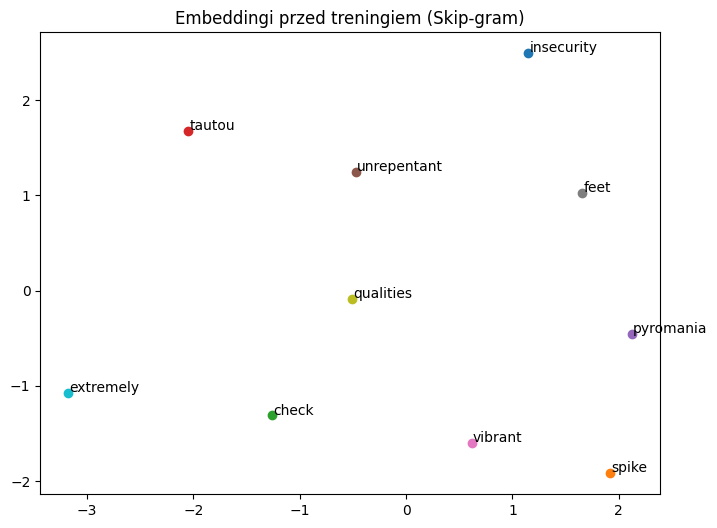

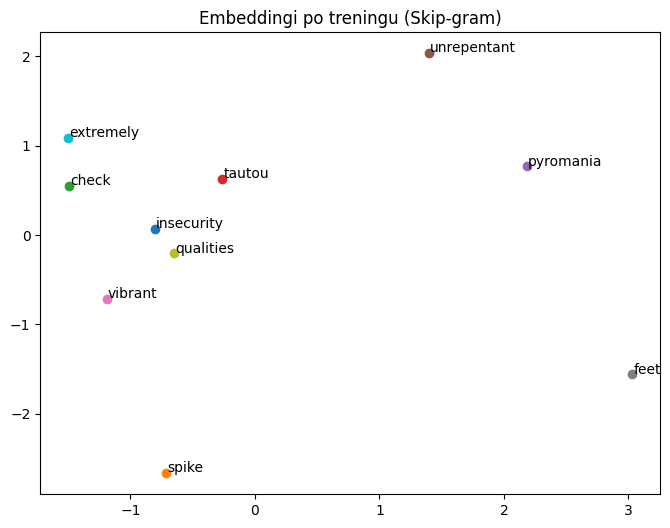

Podobieństwo kosinusowe przed treningiem:
 [[ 1.   -0.01 -0.12  0.29  0.39  0.07 -0.11  0.1  -0.19 -0.49]
 [-0.01  1.   -0.29 -0.03  0.36 -0.32  0.3   0.12  0.05 -0.24]
 [-0.12 -0.29  1.   -0.09  0.06 -0.35  0.3  -0.46 -0.44  0.33]
 [ 0.29 -0.03 -0.09  1.   -0.52 -0.05 -0.33 -0.16  0.09  0.19]
 [ 0.39  0.36  0.06 -0.52  1.    0.2   0.28  0.12 -0.15 -0.57]
 [ 0.07 -0.32 -0.35 -0.05  0.2   1.   -0.32  0.09  0.58  0.02]
 [-0.11  0.3   0.3  -0.33  0.28 -0.32  1.   -0.15  0.23 -0.39]
 [ 0.1   0.12 -0.46 -0.16  0.12  0.09 -0.15  1.   -0.04 -0.42]
 [-0.19  0.05 -0.44  0.09 -0.15  0.58  0.23 -0.04  1.    0.05]
 [-0.49 -0.24  0.33  0.19 -0.57  0.02 -0.39 -0.42  0.05  1.  ]]
Podobieństwo kosinusowe po treningu:
 [[ 1.    0.23  0.35  0.61 -0.05 -0.08  0.24 -0.13  0.39  0.19]
 [ 0.23  1.   -0.1  -0.06 -0.12 -0.32  0.47  0.12  0.51  0.15]
 [ 0.35 -0.1   1.    0.27 -0.66 -0.23  0.42 -0.47  0.09  0.38]
 [ 0.61 -0.06  0.27  1.   -0.13 -0.07 -0.29 -0.08 -0.01  0.29]
 [-0.05 -0.12 -0.66 -0.13  1.    0.2

In [17]:
embeddings_after = W1[selected_idxs]
cos_sim_after = np.dot(embeddings_after, embeddings_after.T) / (
    np.linalg.norm(embeddings_after, axis=1)[:, None] * np.linalg.norm(embeddings_after, axis=1)[None, :]
)

def plot_embeddings(embeddings, words, title):
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(embeddings)
    plt.figure(figsize=(8,6))
    for i, word in enumerate(words):
        plt.scatter(emb_2d[i,0], emb_2d[i,1])
        plt.text(emb_2d[i,0]+0.01, emb_2d[i,1]+0.01, word)
    plt.title(title)
    plt.show()

plot_embeddings(embeddings_before, selected_words, "Embeddings before training (Skip-gram)")
plot_embeddings(embeddings_after, selected_words, "Embeddings after training (Skip-gram)")

print("Cosine similarity before training:\n", np.round(cos_sim_before, 2))
print("Cosine similarity after training:\n", np.round(cos_sim_after, 2))